# Homework 8 - QP4: QFT (150 pts)

Recall, in the overview introduction of this course, the QFT example of a sine-wave waveform to obtain its frequency spectrum.  We will try that in this assignment. 



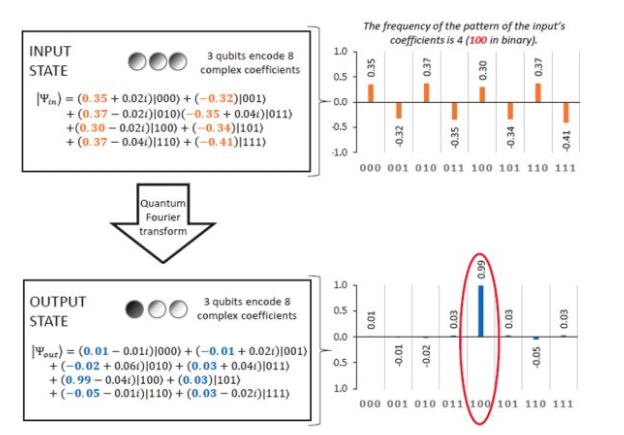

<u>**Note:**</u> the frequency is 4 because the 'unit' time is $N=2^3=8$, and each 'sine' waveform takes 010=2 slots to complete → period is T=2. Hence, there are 4 sine waves within the 'unit' time of N=8, i.e., 4 = unit-time/T = N/T = 8/2 = (100) sinewave waveforms. Therefore, the frequency is 4.

This assignment will demonstrate the equivalence of QFT and DFT: The QFT we perform on the basis states ends up doing the DFT on the amplitudes of the quantum state as you measure the output in the computational basis, and it produces the Fourier-Transformed spectrum of the amplitude waveform $\alpha_j$ vs. $j$:

$$|\tilde{\psi}\rangle = \hat{F}|\psi\rangle = \sum_{j=0}^{N-1} \alpha_j \hat{F}|j\rangle = \sum_{j=0}^{N-1} \alpha_j|j\rangle = \sum_{j=0}^{N-1} \tilde{\alpha}_j|j\rangle$$

We will do this for a 3-qubit circuit and a 5-qubit circuit. The 3-qubit circuit is to verify the above result. The 5-qubit circuits are to test a sine-wave and different square waves with a different period.

The most difficult part in this assignment was: *how do we prepare the input waveform on the amplitude so that the amplitudes show a sine-wave or a certain square-wave pattern?* If you observe the above input waveform, we can see that the amplitudes have a negative sign for every odd integer basis state, and the odd integer basis for when LSB=1. If LSB=0, then the basis state is the even integer. So, we can use a phase-type query to prepare the input state like this:

$$|000\rangle \rightarrow |{+}\rangle^{\otimes 3} = \frac{1}{\sqrt{8}} \sum_{x=0}^{7} |x\rangle \rightarrow \frac{1}{\sqrt{8}} \sum_{x=0}^{7} (-1)^x |x\rangle$$

which can be done by applying a Z-gate to the basis state, $q_0$. The first step creates a uniform superposition with the Hadamard transform. Then the next step, Z(0) flips the sign of every odd state amplitude (same as the phase query). This completes the input state preparation for the sine wave input. Let us try this first on the 3-qubit circuit and then, on the 5-qubit circuit: (1) 40 points, (2) 110 points.

**(1)** <u>On a 3-qubit circuit</u>, prepare the **input waveform by applying the Hadamard to every qubit and then a Z-gate to only the LSB qubit** (i.e., Z(0)). **(A)** Sketch the input waveform where the x-axis (abscissa) is the basis states: 000 through 111. What is the **period T**? What is the expected **frequency**? [Hint: here, the '*unit time*' is the entire x-axis range from 000 to 111, hence 1000. Frequency = unit time / Period T. Frequency is the number of full waveforms within the unit time (the whole range).] **(B)** Build the **quantum circuit** and **simulate** it. What is the **measured frequency**? Does it agree with your expectation? **(C) Run the same circuit on IBM Hardware. Is your hardware result consistent with the simulated result?**
**Report (A), (B) and (C).**

(<u>Note</u>) The Unitary operators $U_2 = (I\otimes Z\otimes I)(H\otimes H\otimes H) = H\otimes ZH\otimes H$, and $U_3 = (Z\otimes I\otimes I)(H\otimes H\otimes H) = ZH\otimes H\otimes H$ are also Hermitian and hence they both have eigenvalues $\pm 1$, each threefold degenerate.

**(2)** <u>On a 5-qubit circuit</u>, prepare the input waveforms by applying the **H gate to all qubits, and the Z-gate to only one qubit at a time: Z(0), Z(1), Z(2), Z(3), Z(4)**. For each case, plot the input waveform (amplitude) with the x-axis showing the basis states from $|00000\rangle$ to $|11111\rangle$. Note: *The Z(0) case is the sine wave; and the Z(1), Z(2), Z(3), Z(4) cases are a square wave* with a different period T. What is the **Period** for each case? What is the **frequency** ($f_1$) of the fundamental harmonic for each case? Build the **QFT quantum circuit for each input waveform** and **simulate** it. Does the **measured frequency** of the fundamental harmonic agree with your calculated value? In the **measured frequency spectrum**, do you see the frequencies of the odd harmonics with the expected intensities for each harmonic? **Perform the IBM Hardware computation and compare your hardware result with the Simulation result**.

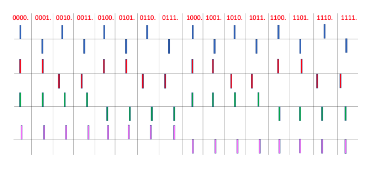

<u>**Report**</u> EVERYTHING. 

<u>Note:</u> Attention will be paid to the bold-faced items.

<u>Note:</u> The square waveform has the odd harmonics as shown below.

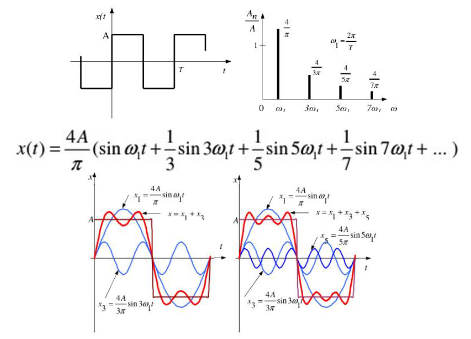

**Also Note**: According to the classical Discrete FT -- the frequency spectrum should have its intensity (amplitude squared) decreasing monotonically for higher harmonics. I do not have a clear explanation for why the QFT result shows a symmetry in the histogram. A guess may be that **the two frequencies that add to '0000'** (i.e., 10000) **are being *IDENTIFIED***. A similar pattern was observed in a quantum counting algorithm. The frequencies are correct in that it produces the ODD HARMONICS for the square wave, but the intensities (probabilities) are wrong, and they appear around the center frequency in a mirror-image. This probably has something to do with the **entire range of the TIME axis** (for the input wave train) **being taken as the UNIT** time (1sec).

Anyway, the probabilities appearing as a mirror image around the center (equivalently, the **two frequencies that add to ZERO are being IDENTIFIED**, such as in 0011 + 1101 = 10000 = '0000' for the 4-qubit circuit) is a question that need be answered/explained. You are welcome to challenge yourself to explain it clearly. But your inability to explain it will not cost you any point in grading.

<span style="color:red">Note that the expected intensity (or probability) distribution is a monotonic decrease with increasing frequency. But in our QC, the two output probabilities whose basis states add to 10000='0000' for the four qubit circuits are being Identified (equal probability) and hence the two probabilities should be added and the sum should be used as the correct probability.</span>

NEXT PAGE shows an example qiskit code for the 3-qubit case.

```Python
from qiskit import QuantumCircuit, transpile 
from qiskit.quantum_info import Statevector 
from qiskit.visualization import plot_histogram 
import matplotlib.pyplot as plt  #to plot amplitudes of statevector 
# from qiskit.providers.ibmq import least_busy 
import numpy as np

### PREPARE THE INPUT WAVEFORM 
nbits=3 
qc=QuantumCircuit(nbits, nbits) 
for i in range(nbits):  
    qc.h(i) 
qc.z(2)  #forms a sinewave of a different periodicity 
qc.barrier() 
qc.draw(output='mpl', style='iqp')

### PREPARE FOR SIMULATION AND PLOT THE STATE VECTOR 
from qiskit_aer import Aer 
simulator = Aer.get_backend('qasm_simulator') 
sim_circuit = transpile(qc, backend=simulator) 
sim_circuit.save_statevector()  #simulator saves statevector 
QuantumCircuit.save_statevector() 
sim_job = simulator.run(sim_circuit) 
sim_result = sim_job.result() 
statevector=sim_result.get_statevector(qc) 
amplitudes=(statevector) 
# to use YYY as real arrays, use `np.asarray(YYY,float)` 
amplitudes=np.asarray(amplitudes,dtype=float)   
binaries=[] 
for i in range(0,len(amplitudes)): 
    binaries +=['{0:03b}'.format(i)] 
plt.figure(figsize=(14,6)) 
plt.bar(binaries,amplitudes) 
plt.ylabel('Input Coefficients') 
plt.show()

#### THE QFT CIRCUIT ON THE STATEVECTOR  
##Define the qft function 
def qft(qcn,nbits):  #QFT on nbits qubits 
    for i in range(nbits-1,-1,-1): 
        qcn.h(i) 
         5 
        for j in range(i-1, -1, -1): 
            qcn.cp(np.pi/(2**(i-j)),j,i) 
        qcn.barrier() 
    for i in range(int(nbits/2)): 
        qcn.swap(i, nbits-1-i)      
         
qft(qc, nbits)  #form the QFT circuit 
qc.barrier() 
for i in range(nbits): 
    qc.measure(i,i) 
qc.draw(output='mpl',style='iqp')

###CONDUCT SIMULATION and PLOT HISTOGRAM 
sim_circuit = transpile(qc, backend=simulator) 
sim_job = simulator.run(sim_circuit) 
sim_result = sim_job.result() 
from qiskit.visualization import plot_histogram 
plot_histogram(sim_result.get_counts()) 

#### PERFORM IBM HARDWARE COMPUTATION AND PLOT HISTOGRAM 
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler 
## Load the saved credentials  
service = QiskitRuntimeService() 
device = service.least_busy(operational=True, simulator=False, min_num_qubits=5) 
transpiled_circuit=transpile(qc, device, seed_transpiler=13) 
# Define Sampler 
sampler = Sampler(mode=device) 
# Run Hardware Computation 
job = sampler.run([transpiled_circuit]) 
result=job.result() 
pub_result = result[0] 
classical_data = pub_result.data.c 
plot_histogram(classical_data.get_counts()) 
```

## Part (1) — 3-qubit QFT with Z(0) sine-wave input

### (A) Input waveform analysis

The 3-qubit Hadamard+Z(0) circuit prepares the state:

$$|\psi\rangle = \frac{1}{\sqrt{8}}\sum_{x=0}^{7}(-1)^x|x\rangle$$

The amplitudes alternate $+1/\sqrt{8}$ and $-1/\sqrt{8}$ for even/odd basis states, forming one full cycle every 2 slots.

- **Period T = 2** (in units of basis-state index steps)  
- **Unit time = N = 8**  
- **Expected frequency f = N/T = 8/2 = 4**


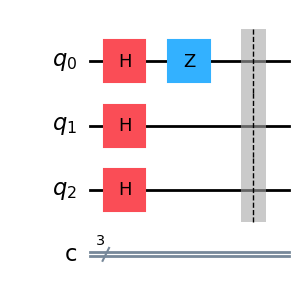

In [9]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

# ── Part (1A): 3-qubit input waveform ──
nbits = 3
qc = QuantumCircuit(nbits, nbits)
for i in range(nbits):
    qc.h(i)
qc.z(0)   # Z on LSB (qubit 0) → sine-wave pattern
qc.barrier()

qc.draw(output='mpl', style='iqp')


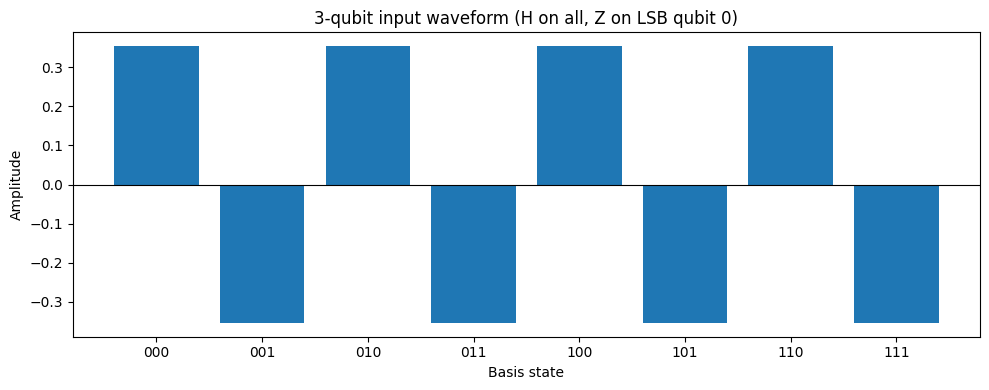

Period T = 2, Expected frequency = 4 = N/T = 8/2


In [10]:
from qiskit_aer import Aer

simulator = Aer.get_backend('statevector_simulator')
sv = Statevector(qc)          # exact statevector before measurement

amplitudes = np.real(sv.data)
binaries = [f'{i:03b}' for i in range(2**nbits)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(binaries, amplitudes)
ax.set_xlabel('Basis state')
ax.set_ylabel('Amplitude')
ax.set_title('3-qubit input waveform (H on all, Z on LSB qubit 0)')
ax.axhline(0, color='k', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"Period T = 2, Expected frequency = {2**nbits // 2} = N/T = {2**nbits}/2")


### (B) Build the QFT circuit and simulate


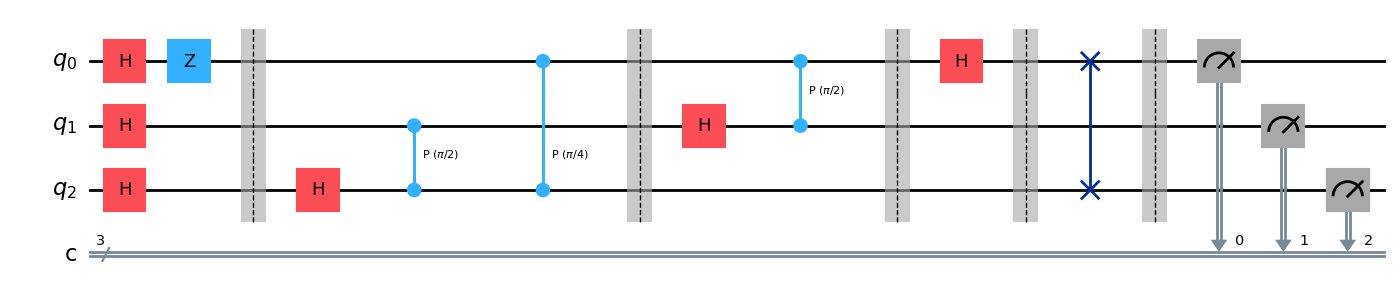

In [11]:
def qft(circuit, n):
    """Append in-place QFT on the first n qubits."""
    for i in range(n - 1, -1, -1):
        circuit.h(i)
        for j in range(i - 1, -1, -1):
            circuit.cp(np.pi / (2 ** (i - j)), j, i)
        circuit.barrier()
    # Swap to correct bit ordering
    for i in range(n // 2):
        circuit.swap(i, n - 1 - i)

# Build full circuit: input prep + QFT + measure
qc_full = QuantumCircuit(nbits, nbits)
for i in range(nbits):
    qc_full.h(i)
qc_full.z(0)
qc_full.barrier()
qft(qc_full, nbits)
qc_full.barrier()
for i in range(nbits):
    qc_full.measure(i, i)

qc_full.draw(output='mpl', style='iqp')


Simulation counts: {'100': 8192}
Measured frequency (dominant bin) = 4
Expected frequency = 4


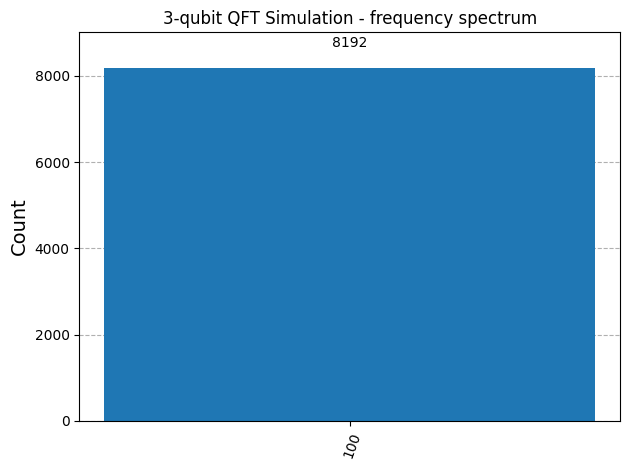

In [14]:
# ── Part (1B): Simulation ──
sim_backend = Aer.get_backend('qasm_simulator')
sim_circuit = transpile(qc_full, backend=sim_backend)
sim_job = sim_backend.run(sim_circuit, shots=8192)
sim_result = sim_job.result()
sim_counts = sim_result.get_counts()

print("Simulation counts:", sim_counts)
peak_bin = max(sim_counts, key=sim_counts.get)
measured_freq = int(peak_bin, 2)
print(f"Measured frequency (dominant bin) = {measured_freq}")
print(f"Expected frequency = 4")

fig_sim = plot_histogram(sim_counts, title='3-qubit QFT Simulation - frequency spectrum')
fig_sim.tight_layout()
display(fig_sim)


### (C) IBM Hardware run


qiskit_runtime_service.__init__:WARNING:2026-04-24 13:56:54,579: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-24 13:56:55,304: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-24 13:56:57,659: Using instance: open-instance, plan: open


Using device: ibm_kingston
Job ID: d7lqtqk3g2mc7391mf60  - waiting for result...
Hardware counts: {'100': 3772, '101': 48, '110': 32, '000': 135, '011': 15, '010': 60, '111': 22, '001': 12}


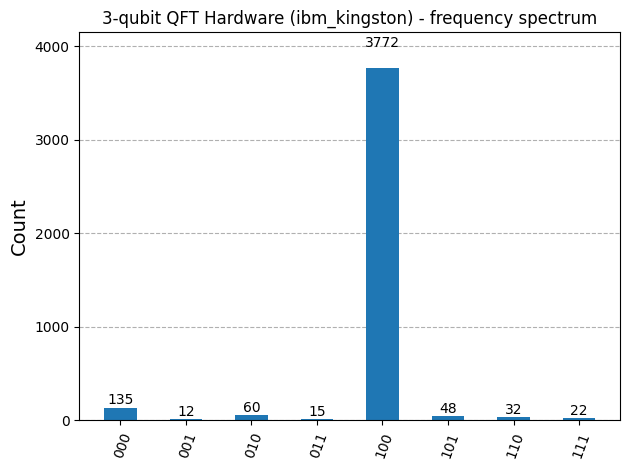

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Load IBM credentials from local apikey.json
import json as _json
with open('/Users/yuyaohuang/Github/EE520_QC_and_device/apikey.json') as _f:
    _key = _json.load(_f)['apikey']

QiskitRuntimeService.save_account(channel='ibm_quantum_platform', token=_key, overwrite=True)
service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Pick least-busy real device with >= 5 qubits
device = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"Using device: {device.name}")

transpiled_hw = transpile(qc_full, device, seed_transpiler=42)

sampler = Sampler(mode=device)
hw_job = sampler.run([transpiled_hw])
print(f"Job ID: {hw_job.job_id()}  - waiting for result...")
hw_result = hw_job.result()

pub_result = hw_result[0]
hw_counts = pub_result.data.c.get_counts()
print("Hardware counts:", hw_counts)

fig_hw = plot_histogram(hw_counts, title=f'3-qubit QFT Hardware ({device.name}) - frequency spectrum')
fig_hw.tight_layout()
display(fig_hw)


## Part (2) — 5-qubit QFT: Z(k) for k = 0, 1, 2, 3, 4

For each case:
- Apply **H to all 5 qubits**, then **Z to qubit k only**
- Amplitudes: $(-1)^{b_k}$ where $b_k$ is the k-th bit (0-indexed from LSB)
- **Period** of the resulting pattern in terms of basis-state index:
  - Z(0): flips every other state → T = 2, f₁ = 32/2 = **16**
  - Z(1): flips every 2nd pair  → T = 4, f₁ = 32/4 = **8**
  - Z(2): T = 8,  f₁ = **4**
  - Z(3): T = 16, f₁ = **2**
  - Z(4): T = 32, f₁ = **1**

The QFT should identify the fundamental harmonic at f₁ and the odd harmonics (3f₁, 5f₁, …) for the square-wave cases (Z(1)–Z(4)).


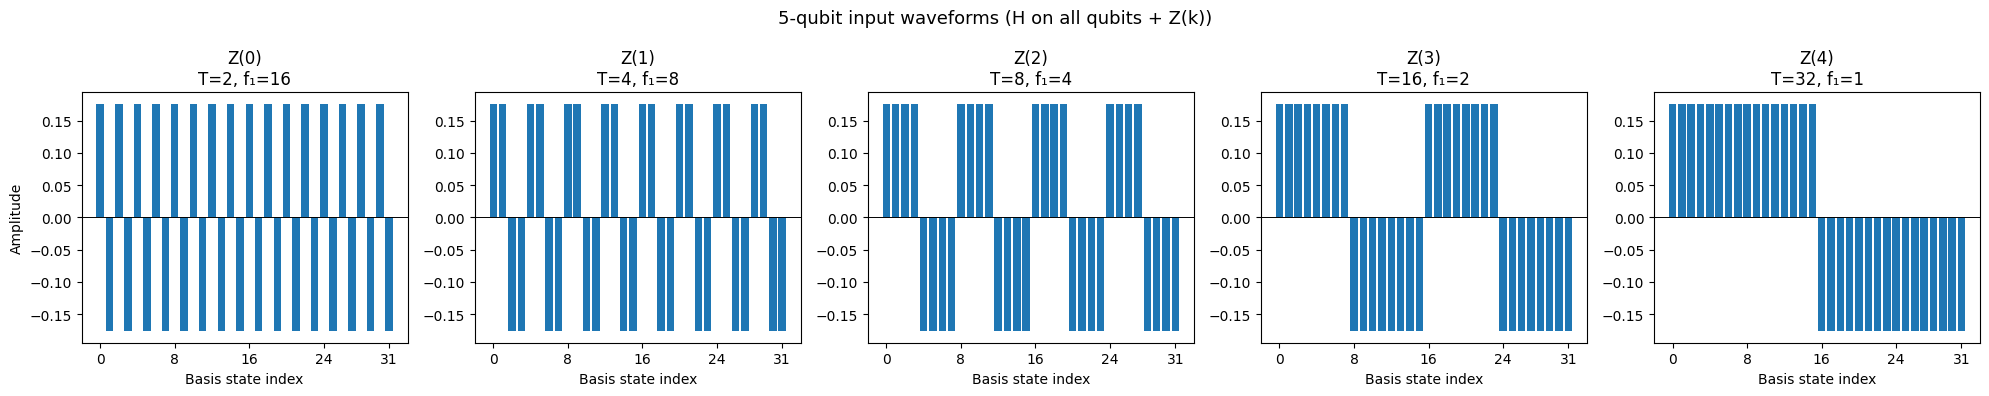

Z(0): Period T=2, fundamental frequency f₁=16 (sine wave)
Z(1): Period T=4, fundamental frequency f₁=8 (square wave)
Z(2): Period T=8, fundamental frequency f₁=4 (square wave)
Z(3): Period T=16, fundamental frequency f₁=2 (square wave)
Z(4): Period T=32, fundamental frequency f₁=1 (square wave)


In [16]:
# ── Part (2A): Plot all 5 input waveforms ──
nbits5 = 5
N5 = 2 ** nbits5   # 32

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
periods = {0: 2, 1: 4, 2: 8, 3: 16, 4: 32}
freqs   = {k: N5 // periods[k] for k in range(5)}

for k in range(5):
    qc_in = QuantumCircuit(nbits5)
    for i in range(nbits5):
        qc_in.h(i)
    qc_in.z(k)
    sv = Statevector(qc_in)
    amps = np.real(sv.data)
    binaries5 = [f'{i:05b}' for i in range(N5)]
    ax = axes[k]
    ax.bar(range(N5), amps, width=0.8)
    ax.set_title(f'Z({k})\nT={periods[k]}, f₁={freqs[k]}')
    ax.set_xlabel('Basis state index')
    ax.set_ylabel('Amplitude' if k == 0 else '')
    ax.axhline(0, color='k', linewidth=0.7)
    ax.set_xticks([0, 8, 16, 24, 31])

plt.suptitle('5-qubit input waveforms (H on all qubits + Z(k))', fontsize=13)
plt.tight_layout()
plt.show()

for k in range(5):
    wtype = 'sine wave' if k == 0 else 'square wave'
    print(f"Z({k}): Period T={periods[k]}, fundamental frequency f₁={freqs[k]} ({wtype})")


Z(0): expected f₁=16, measured dominant bin=16
Z(1): expected f₁=8, measured dominant bin=8
Z(2): expected f₁=4, measured dominant bin=4
Z(3): expected f₁=2, measured dominant bin=30
Z(4): expected f₁=1, measured dominant bin=1


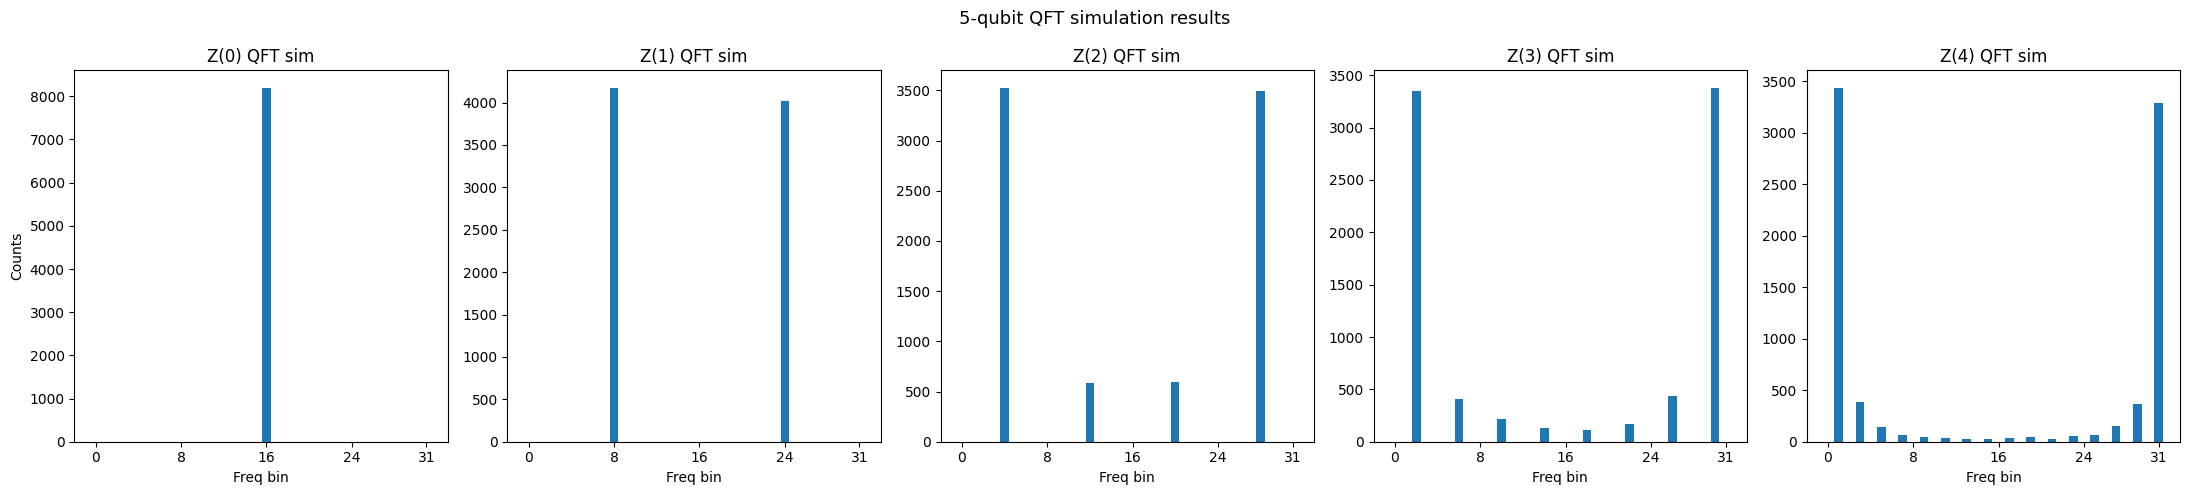

In [17]:
# ── Part (2B): QFT + simulation for each Z(k) ──
sim_backend5 = Aer.get_backend('qasm_simulator')

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

qc_hw_list = []   # store transpiled circuits for hardware

for k in range(5):
    qc5 = QuantumCircuit(nbits5, nbits5)
    for i in range(nbits5):
        qc5.h(i)
    qc5.z(k)
    qc5.barrier()
    qft(qc5, nbits5)
    qc5.barrier()
    for i in range(nbits5):
        qc5.measure(i, i)

    tc = transpile(qc5, backend=sim_backend5)
    job = sim_backend5.run(tc, shots=8192)
    counts = job.result().get_counts()

    # Find dominant bin
    peak = max(counts, key=counts.get)
    mfreq = int(peak, 2)
    print(f"Z({k}): expected f₁={N5//periods[k]}, measured dominant bin={mfreq}")

    # Plot
    all_bins = {f'{i:05b}': 0 for i in range(N5)}
    all_bins.update(counts)
    ax = axes[k]
    ax.bar(range(N5), [all_bins[f'{i:05b}'] for i in range(N5)], width=0.8)
    ax.set_title(f'Z({k}) QFT sim')
    ax.set_xlabel('Freq bin')
    if k == 0:
        ax.set_ylabel('Counts')
    ax.set_xticks([0, 8, 16, 24, 31])

    qc_hw_list.append(qc5)

plt.suptitle('5-qubit QFT simulation results', fontsize=13)
plt.tight_layout()
plt.show()


qiskit_runtime_service.backends:WARNING:2026-04-24 13:57:51,419: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-24 13:57:52,443: Using instance: open-instance, plan: open


Using device: ibm_fez
Job ID: d7lqu8baq2pc73a0t490  — waiting for result...
Z(0) HW peak bin: 10000
Z(1) HW peak bin: 11000
Z(2) HW peak bin: 00100
Z(3) HW peak bin: 00010
Z(4) HW peak bin: 00001


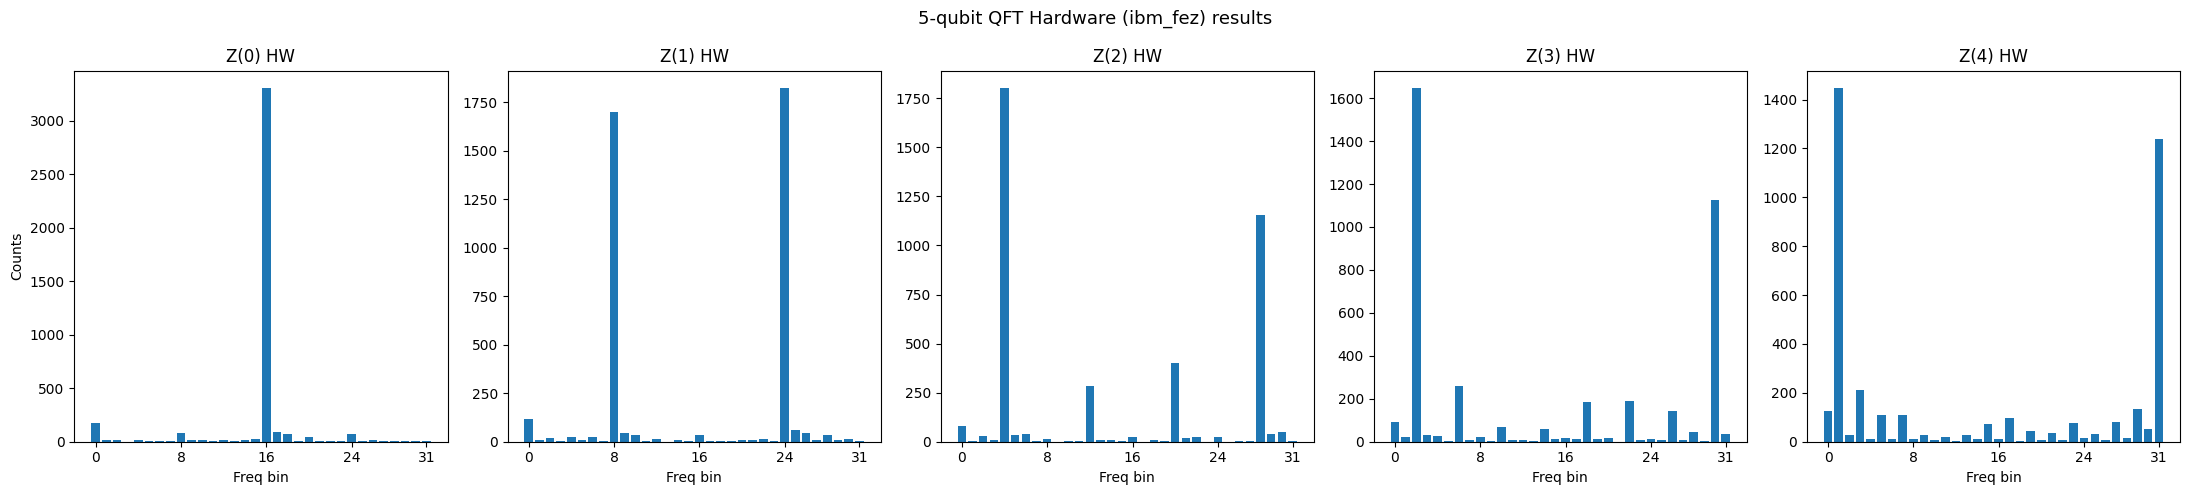

In [18]:
# ── Part (2C): IBM Hardware for all 5 circuits ──
device5 = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
print(f"Using device: {device5.name}")

sampler5 = Sampler(mode=device5)
transpiled_hw5 = [transpile(qc, device5, seed_transpiler=42) for qc in qc_hw_list]

hw_job5 = sampler5.run(transpiled_hw5)
print(f"Job ID: {hw_job5.job_id()}  — waiting for result...")
hw_result5 = hw_job5.result()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for k in range(5):
    pub = hw_result5[k]
    hw_counts_k = pub.data.c.get_counts()
    all_bins = {f'{i:05b}': 0 for i in range(N5)}
    all_bins.update(hw_counts_k)
    ax = axes[k]
    ax.bar(range(N5), [all_bins[f'{i:05b}'] for i in range(N5)], width=0.8)
    ax.set_title(f'Z({k}) HW')
    ax.set_xlabel('Freq bin')
    if k == 0:
        ax.set_ylabel('Counts')
    ax.set_xticks([0, 8, 16, 24, 31])
    print(f"Z({k}) HW peak bin: {max(hw_counts_k, key=hw_counts_k.get)}")

plt.suptitle(f'5-qubit QFT Hardware ({device5.name}) results', fontsize=13)
plt.tight_layout()
plt.show()
